In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from setuptools.command.rotate import rotate


In [5]:
df = pd.read_csv("Website- Data Analysis - Iscale data-export.csv")
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [6]:
df.columns = df.iloc[0]
df.head(5)

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [7]:
#df = df.drop(index = 0).reset_index(drop = True)
df.reset_index(drop = True).head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [8]:
df.columns = ["Channel Group","DateHour", "Users", "Sessions" , "Engaged Sessions", "Average engaged time per session", "Engaged sessions per user", "Events per session", "Engagement rate", "Event count"]
df.columns

Index(['Channel Group', 'DateHour', 'Users', 'Sessions', 'Engaged Sessions',
       'Average engaged time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Channel Group                     3183 non-null   str  
 1   DateHour                          3183 non-null   str  
 2   Users                             3183 non-null   str  
 3   Sessions                          3183 non-null   str  
 4   Engaged Sessions                  3183 non-null   str  
 5   Average engaged time per session  3183 non-null   str  
 6   Engaged sessions per user         3183 non-null   str  
 7   Events per session                3183 non-null   str  
 8   Engagement rate                   3183 non-null   str  
 9   Event count                       3183 non-null   str  
dtypes: str(10)
memory usage: 248.8 KB


In [10]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format = "%Y%m%d%H", errors = 'coerce')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Channel Group                     3183 non-null   str           
 1   DateHour                          3182 non-null   datetime64[us]
 2   Users                             3183 non-null   str           
 3   Sessions                          3183 non-null   str           
 4   Engaged Sessions                  3183 non-null   str           
 5   Average engaged time per session  3183 non-null   str           
 6   Engaged sessions per user         3183 non-null   str           
 7   Events per session                3183 non-null   str           
 8   Engagement rate                   3183 non-null   str           
 9   Event count                       3183 non-null   str           
dtypes: datetime64[us](1), str(9)
memory usage: 248.8 KB


In [12]:
numeric_cols = df.columns.drop(["Channel Group", "DateHour"])
numeric_cols


Index(['Users', 'Sessions', 'Engaged Sessions',
       'Average engaged time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count'],
      dtype='str')

In [13]:
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric, errors = "coerce")
df[numeric_cols]

,Users,Sessions,Engaged Sessions,Average engaged time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,237.0,300.0,144.0,47.526667,0.607595,4.673333,0.480000,1402.0
2,208.0,267.0,132.0,32.097378,0.634615,4.295880,0.494382,1147.0
3,188.0,233.0,115.0,39.939914,0.611702,4.587983,0.493562,1069.0
4,187.0,256.0,125.0,32.160156,0.668449,4.078125,0.488281,1044.0
...,...,...,...,...,...,...,...,...
3178,0.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,2.0
3179,0.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,2.0
3180,0.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,2.0
3181,0.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,2.0


In [47]:
df["Hour"] = df["DateHour"].dt.hour
df.head(1)

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Average engaged time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Session primary channel group (Default channel...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Channel Group                     3183 non-null   str           
 1   DateHour                          3182 non-null   datetime64[us]
 2   Users                             3182 non-null   float64       
 3   Sessions                          3182 non-null   float64       
 4   Engaged Sessions                  3182 non-null   float64       
 5   Average engaged time per session  3182 non-null   float64       
 6   Engaged sessions per user         3182 non-null   float64       
 7   Events per session                3182 non-null   float64       
 8   Engagement rate                   3182 non-null   float64       
 9   Event count                       3182 non-null   float64       
 10  Hour                              3182 non-null   float64  

In [16]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average engaged time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# Sessions and Users Over Time

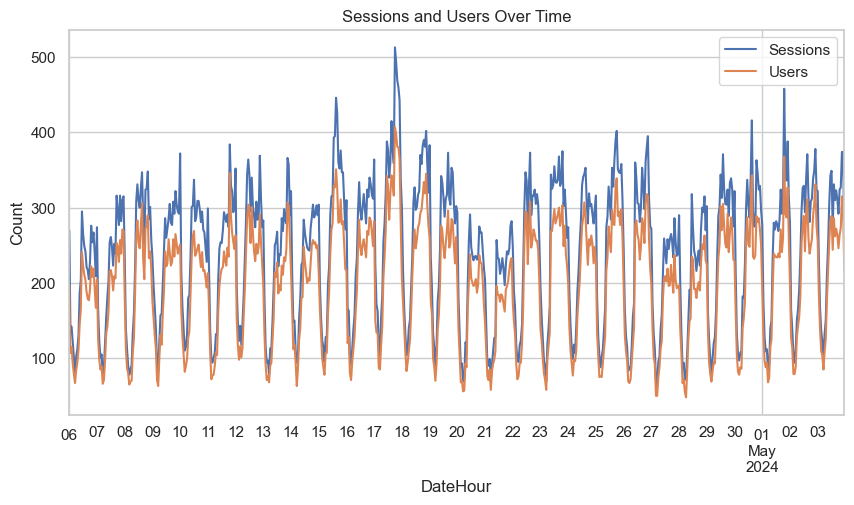

In [17]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Sessions","Users"]].sum().plot(ax = plt.gca())
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.title("Sessions and Users Over Time")
plt.show()

# Total Users by channel

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9656\1282790108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_User_byChannels, x = "Channel Group", y = "Users",  palette = "viridis")


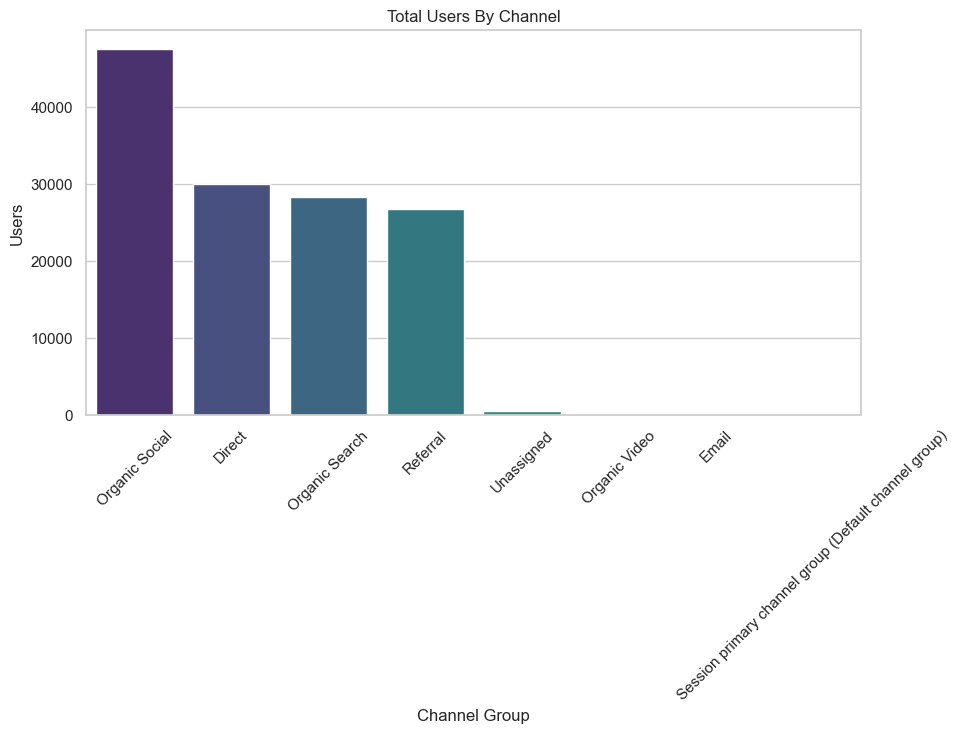

In [18]:
plt.figure(figsize=(10,5))
df_User_byChannels = df.groupby("Channel Group")["Users"].sum().sort_values( ascending = False).reset_index()
sns.barplot(data = df_User_byChannels, x = "Channel Group", y = "Users",  palette = "viridis")
plt.title("Total Users By Channel")
plt.xticks(rotation = 45)
plt.show()

# Average Engagement Time by Channel

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9656\1420893036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_average_channel_engagement  , x = "Channel Group", y = "Average engaged time per session", estimator = np.mean, palette = "magma")


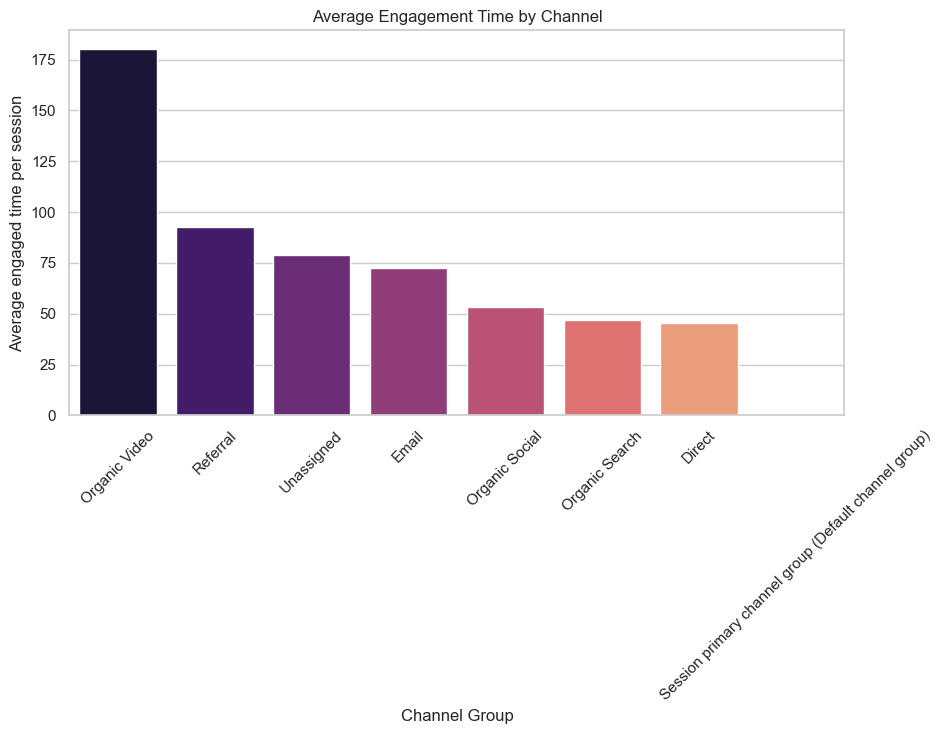

In [69]:
plt.figure(figsize=(10,5))
df_average_channel_engagement = df.groupby("Channel Group")["Average engaged time per session"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data = df_average_channel_engagement  , x = "Channel Group", y = "Average engaged time per session", estimator = np.mean, palette = "magma")
plt.title("Average Engagement Time by Channel")
plt.xticks(rotation = 45)
plt.show()

# Engagement Rate Distribution by Channel

C:\Users\MY PC\AppData\Local\Temp\ipykernel_9656\403251886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "Channel Group", y = "Engagement rate", palette = "coolwarm")


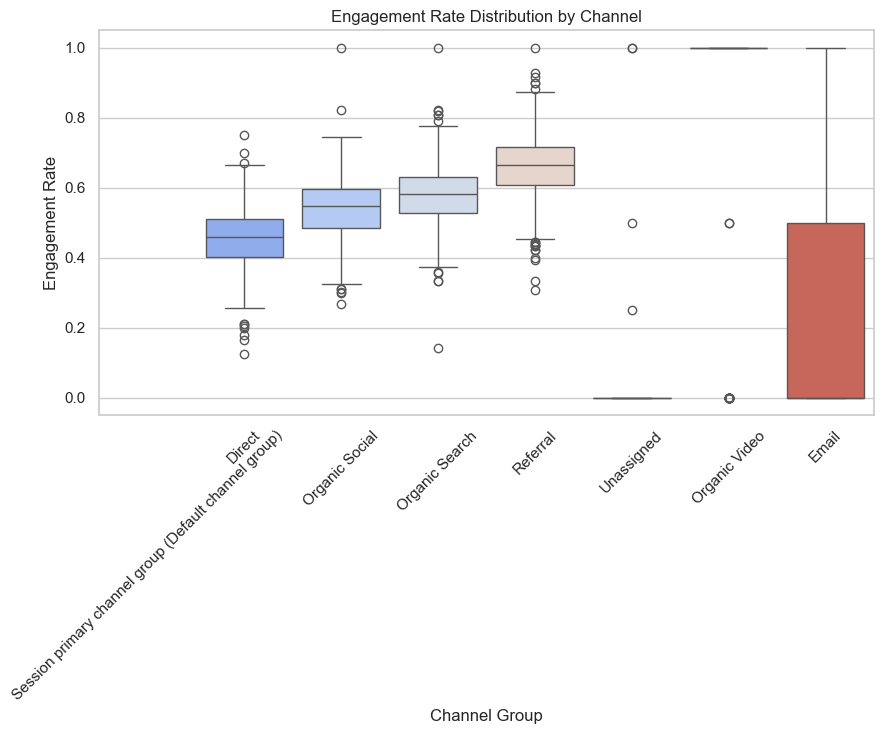

In [20]:
#df_engagement_rate_by_channel = df.groupby("Channel Group")["Engagement rate"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x = "Channel Group", y = "Engagement rate", palette = "coolwarm")
plt.title("Engagement Rate Distribution by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Engagement Rate")
plt.xticks(rotation = 45)
plt.show()


**Key Insights:**
Refferal Channel is the best performer.
- Hight median engagement + less spread = Relialble channel
Organic search is strong and consistent
- SEO ka result achha dikh raha hai

# Engaged vs Non Engaged Sessions

In [40]:
session_df = df.groupby("Channel Group")[["Sessions","Engaged Sessions"]].sum().reset_index()
session_df["Non_Engaged"] = session_df["Sessions"]-session_df["Engaged Sessions"]
session_df_melted = session_df.melt(id_vars="Channel Group", value_vars = ["Engaged Sessions","Non_Engaged"]).sort_values(by = "value", ascending = False)
session_df_melted

,Channel Group,variable,value
3,Organic Social,Engaged Sessions,32697.0
11,Organic Social,Non_Engaged,27930.0
5,Referral,Engaged Sessions,20653.0
8,Direct,Non_Engaged,19960.0
2,Organic Search,Engaged Sessions,19425.0
0,Direct,Engaged Sessions,17243.0
10,Organic Search,Non_Engaged,13947.0
13,Referral,Non_Engaged,10337.0
15,Unassigned,Non_Engaged,555.0
4,Organic Video,Engaged Sessions,109.0


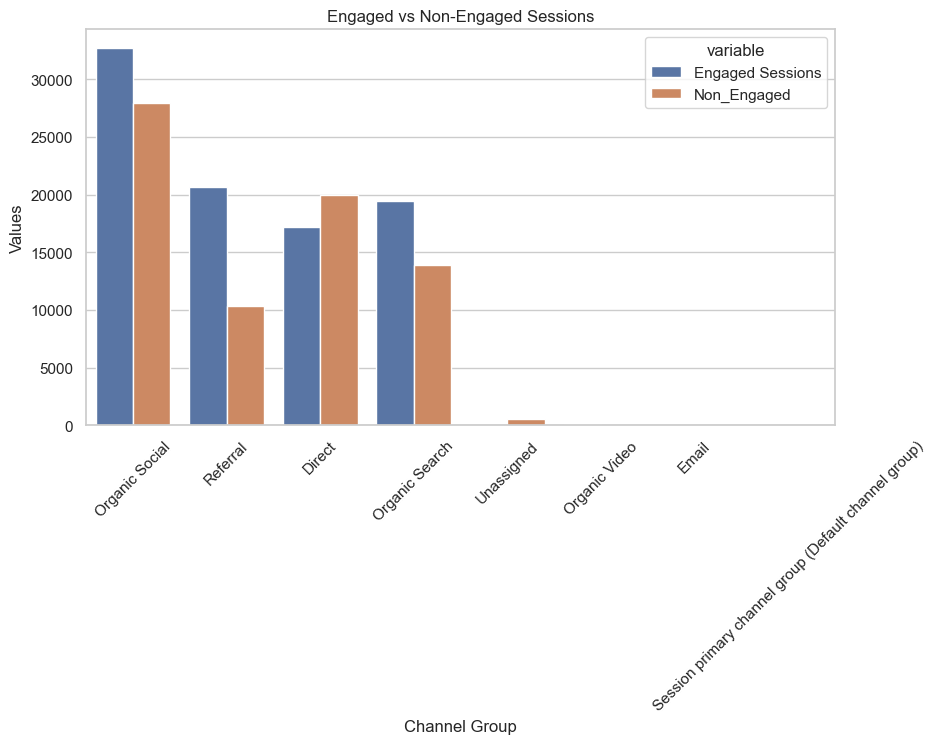

In [41]:
plt.figure(figsize=(10,5))
sns.barplot(data = session_df_melted,x = "Channel Group", y = "value", hue = "variable" )
plt.title("Engaged vs Non-Engaged Sessions")
plt.xlabel("Channel Group")
plt.ylabel("Values")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


# Traffic by Hours and channel

In [51]:
heatmap_data = df.groupby(["Hour", "Channel Group"])["Sessions"].sum().unstack().fillna(0)
heatmap_data

Channel Group,Direct,Organic Search,Organic Social,Organic Video,Referral,Unassigned,Email
Hour,,,,,,,
0.0,1684.0,1311.0,3917.0,6.0,1204.0,26.0,0.0
1.0,1196.0,984.0,2108.0,5.0,923.0,12.0,0.0
2.0,887.0,804.0,1537.0,2.0,755.0,13.0,1.0
3.0,771.0,606.0,1249.0,2.0,560.0,11.0,0.0
4.0,666.0,535.0,1081.0,2.0,495.0,6.0,1.0
5.0,679.0,506.0,951.0,1.0,453.0,8.0,0.0
6.0,768.0,639.0,1171.0,1.0,565.0,17.0,0.0
7.0,889.0,778.0,1524.0,2.0,743.0,10.0,0.0
8.0,1078.0,938.0,1886.0,4.0,862.0,13.0,0.0


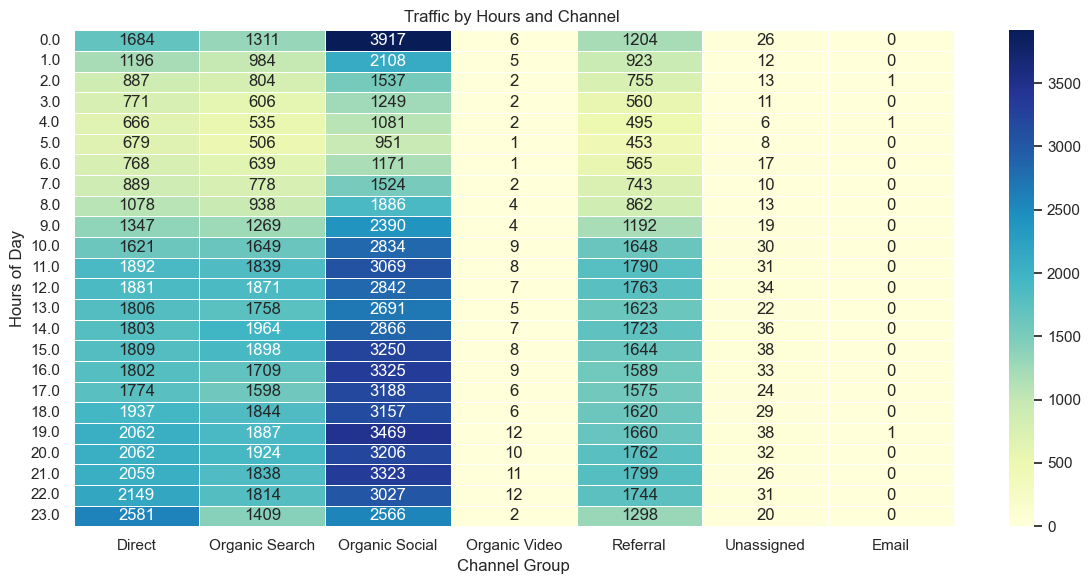

In [55]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data , cmap = "YlGnBu", linewidth = .5, annot = True, fmt='.0f' )
plt.title("Traffic by Hours and Channel ")
plt.xlabel("Channel Group")
plt.ylabel("Hours of Day")
plt.tight_layout()
plt.show()

# Engagement Rate vs Sessions over Time

In [61]:
df.drop(index=0).reset_index(drop=True).head(5)

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Average engaged time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237.0,300.0,144.0,47.526667,0.607595,4.673333,0.480000,1402.0,23.0
1,Organic Social,2024-04-17 19:00:00,208.0,267.0,132.0,32.097378,0.634615,4.295880,0.494382,1147.0,19.0
2,Direct,2024-04-17 23:00:00,188.0,233.0,115.0,39.939914,0.611702,4.587983,0.493562,1069.0,23.0
3,Organic Social,2024-04-17 18:00:00,187.0,256.0,125.0,32.160156,0.668449,4.078125,0.488281,1044.0,18.0
4,Organic Social,2024-04-17 20:00:00,175.0,221.0,112.0,46.918552,0.640000,4.529412,0.506787,1001.0,20.0


In [63]:
df_plot = df.groupby("DateHour")[["Sessions", "Engagement rate"]].mean().reset_index()
df_plot

,DateHour,Sessions,Engagement rate
0,2024-04-06 00:00:00,54.000000,0.450262
1,2024-04-06 01:00:00,35.500000,0.489905
2,2024-04-06 02:00:00,35.500000,0.595759
3,2024-04-06 03:00:00,24.400000,0.446725
4,2024-04-06 04:00:00,25.500000,0.494964
...,...,...,...
667,2024-05-03 19:00:00,54.000000,0.498125
668,2024-05-03 20:00:00,54.500000,0.375790
669,2024-05-03 21:00:00,74.800000,0.471312
670,2024-05-03 22:00:00,62.333333,0.367749


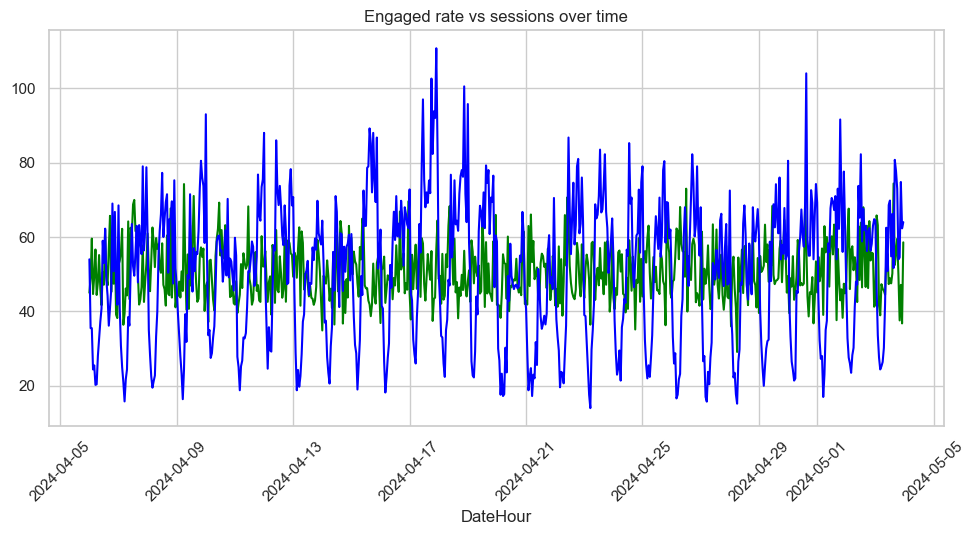

In [67]:
plt.figure(figsize=(10,5))
plt.plot(df_plot[ "DateHour"], df_plot["Engagement rate"]*100, label = "Engagement rate percentage", color = "green" )
plt.plot(df_plot["DateHour"],  df_plot["Sessions"], label = "Sessions", color = "blue" )

plt.title("Engaged rate vs sessions over time")
plt.xlabel("DateHour")
#plt.ylabel("Values")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()